/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/envs/registration.py:481: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['paper_link', 'paper_name', 'tags']
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.seed to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.seed` for environment variables or `env.get_wrapper_attr('seed')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.new_trial` for environment variables or `env.get_wrapper_attr('new_trial')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/

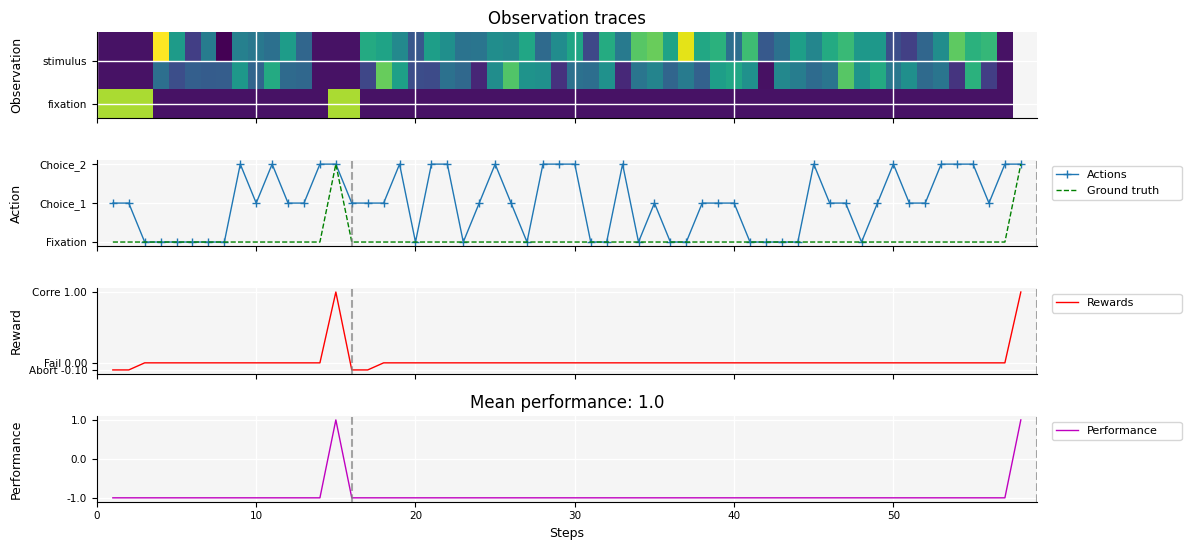

In [15]:
""" Defining a perceptual decision making task (2 choices) """
# import the task from the neurogym library
import neurogym as ngym

# Environment
task = 'PerceptualDecisionMaking-v0'
timing = {
    'fixation': ('choice', (50, 100, 200, 400)),
    'stimulus': ('choice', (100, 200, 400, 800)),
}
kwargs = {'dt': 20, 'timing': timing}
seq_len = 100

# Make supervised dataset
dataset = ngym.Dataset(task, env_kwargs=kwargs, batch_size=16,
                       seq_len=seq_len)

# A sample environment from dataset
env = dataset.env
# Visualize the environment with 2 sample trials
_ = ngym.utils.plot_env(env, num_trials=2)

# Network input and output size
input_size = env.observation_space.shape[0] # 3: fixation - 0, stimulus 1 and 2
output_size = env.action_space.n # 3

In [16]:
import torch
import torch.nn as nn 
from torch.nn import init 
from torch.nn import functional as F 
import math
import numpy as np

""" Construct RNN with Dale's Law """
# hidden layer weight matrix
class EIRecLinear(nn.Module):
    __constants__ = ['bias', 'hidden_size', 'e_prop'] # things don't change with training
    def __init__(self, hidden_size, e_prop, bias=False): # bias (h2h) is True biologically, but for W recovery, False might be better
        super().__init__()
        self.hidden_size = hidden_size
        self.e_prop = e_prop
        self.e_size = int(e_prop * hidden_size)
        self.i_size = hidden_size - self.e_size
        self.weight = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        mask = np.tile([1]*self.e_size+[-1]*self.i_size, (hidden_size, 1)) # W_ij = neuron j (column) -> neuron i
        np.fill_diagonal(mask, 0)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        if bias:
            self.bias = nn.Parameter(torch.Tensor(hidden_size))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        self.weight.data[:, :self.e_size] /= (self.e_size/self.i_size) # there are more E neurons than I neurons, so rescaling the weight by E/I
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight) # fan_in = hidden layer size
            bound = 1 / math.sqrt(fan_in)
            init.uniform_(self.bias, -bound, bound)

    def effective_weight(self):
        return torch.abs(self.weight) * self.mask
    
    def forward(self, input):
        return F.linear(input, self.effective_weight(), self.bias) # input = hidden state (t-1) = r_t-1

# import recurrent
class EIRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dt=None, e_prop=0.8, sigma_rec=0, **kwargs):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.e_size = int(hidden_size * e_prop)
        self.i_size = hidden_size - self.e_size
        self.num_layers = 1
        self.tau = 100
        if dt is None:
            alpha = 1
        else:
            alpha = dt / self.tau
        self.alpha = alpha
        self.oneminusalpha = 1 - alpha
        self._sigma_rec = np.sqrt(2*alpha) * sigma_rec # noise in RNN, sigma * dt/tau --SD-> sigma * sqrt(dt/tau)
        self.input2h = nn.Linear(input_size, hidden_size) # do not constrain the input to hidden being positive, build input -> hidden matrix
        self.h2h = EIRecLinear(hidden_size, e_prop=0.8)

    def init_hidden(self, input):
        batch_size = input.shape[1]
        return (torch.zeros(batch_size, self.hidden_size).to(input.device), torch.zeros(batch_size, self.hidden_size).to(input.device)) # state h, output r

    def recurrence(self, input, hidden):
        state, output = hidden # hidden = (state h, output r)
        total_input = self.input2h(input) + self.h2h(output)
        state = state * self.oneminusalpha + total_input * self.alpha
        state += self._sigma_rec * torch.randn_like(state) # state r: (batch_size, hidden_size)
        output = torch.relu(state) # output: (batch_size, hidden_size)
        return state, output 

    def forward(self, input, hidden=None):
        if hidden is None:
            hidden = self.init_hidden(input)
        output = []
        steps = range(input.size(0)) # input from outside, input.size(0) = timesteps
        for i in steps:
            hidden = self.recurrence(input[i], hidden) # (state, output) at the last timestep
            output.append(hidden[1]) # output = [output_1, output_2, ...]
        output = torch.stack(output, dim=0) # (seq_len, batch_size, hidden_size)
        return output, hidden
    
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, **kwargs):
        super().__init__()
        self.rnn = EIRNN(input_size, hidden_size, **kwargs) 
        self.fc = nn.Linear(self.rnn.e_size, output_size) # fully connected readout, only excitatory neurons have readout

    def forward(self, x): # x is the input data
        rnn_activity, _ = self.rnn(x) # _ is hidden state, call the forward function in EIRNN
        rnn_e = rnn_activity[:, :, :self.rnn.e_size]
        out = self.fc(rnn_e) # (seq_len, batch_size, output_size) = 100, 16, 3
        return out, rnn_activity # out is the output of the whole rnn, rnn_activity is the output r in the rnn

In [17]:
""" Train the teacher RNN """
hidden_size = 50
net = Net(input_size=input_size, 
          hidden_size=hidden_size, 
          output_size=output_size, 
          dt=env.dt, 
          sigma_rec=0) # used to be 0.15 
print(net)

import torch.optim as optim
optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss() # minimizing loss: compare p^​(y) with y; L = -log p(correct); input is number of sample * number of class
running_loss = 0
running_acc = 0
print_step = 200
for i in range(5000): # 5000 times parameter update
    inputs, labels = dataset() # inputs (numpy.darray) = 100*16*3, labels (numpy.darray) = correct answer (100*16), dataset is generated by neurogym

    inputs = torch.from_numpy(inputs).type(torch.float) # device: CPU, type: torch.Tensor, dtype: float32
    labels = torch.from_numpy(labels.flatten()).type(torch.long) # labels = 1600 * 1, all integers, cpu, torch.Tensor, int64

    optimizer.zero_grad() # clear the gradient
    output, activity = net(inputs) # inputs = x (forward function in Net)
    output = output.view(-1, output_size) # reshape into 1600*3
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() # total loss from the rnn
    if i % print_step == (print_step - 1): # print the loss every print_step (update) by mod == 199
        running_loss /= print_step
        print('Step {}, Loss {:0.4f}'.format(i+1, running_loss))
        running_loss = 0

/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.dt to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.dt` for environment variables or `env.get_wrapper_attr('dt')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.new_trial` for environment variables or `env.get_wrapper_attr('new_trial')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.ob to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.ob` for environment variables or `env.get

Net(
  (rnn): EIRNN(
    (input2h): Linear(in_features=3, out_features=50, bias=True)
    (h2h): EIRecLinear()
  )
  (fc): Linear(in_features=40, out_features=3, bias=True)
)
Step 200, Loss 0.5643
Step 400, Loss 0.3858
Step 600, Loss 0.2755
Step 800, Loss 0.2115
Step 1000, Loss 0.1760
Step 1200, Loss 0.1540
Step 1400, Loss 0.1358
Step 1600, Loss 0.1262
Step 1800, Loss 0.1161
Step 2000, Loss 0.1098
Step 2200, Loss 0.1049
Step 2400, Loss 0.0985
Step 2600, Loss 0.0940
Step 2800, Loss 0.0930
Step 3000, Loss 0.0891
Step 3200, Loss 0.0887
Step 3400, Loss 0.0849
Step 3600, Loss 0.0848
Step 3800, Loss 0.0811
Step 4000, Loss 0.0803
Step 4200, Loss 0.0799
Step 4400, Loss 0.0774
Step 4600, Loss 0.0769
Step 4800, Loss 0.0753
Step 5000, Loss 0.0757


(50, 50)
(50, 3)
(3, 40)


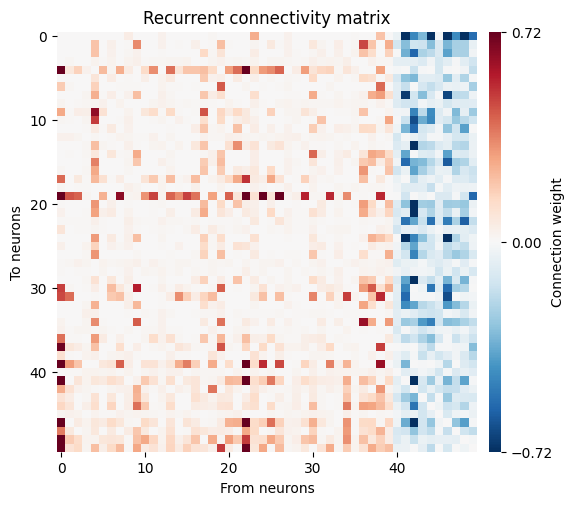

In [18]:
""" Visualize Matrices of RNN with Dale's Law """
W_rec = net.rnn.h2h.effective_weight().detach().numpy()
W_in = net.rnn.input2h.weight.detach().numpy()
W_out = net.fc.weight.detach().numpy()
print(W_rec.shape)
print(W_in.shape)
print(W_out.shape)

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
n_neuron = W_rec.shape[0]
# color scale
wlim = np.percentile(np.abs(W_rec), 99)
wlim = int(wlim * 100) / 100

fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.7, 0.7])
im = ax.imshow(
    W_rec,
    cmap='RdBu_r',
    vmin=-wlim,
    vmax=wlim,
    extent=(-0.5, n_neuron - 0.5,
            n_neuron - 0.5, -0.5),
    interpolation='nearest'
)
plt.xlabel('From neurons')
plt.ylabel('To neurons')
plt.title('Recurrent connectivity matrix')
for loc in ['left', 'right', 'top', 'bottom']:
    ax.spines[loc].set_visible(False)
cax = fig.add_axes([0.82, 0.1, 0.02, 0.7])
cb = plt.colorbar(
    im,
    cax=cax,
    ticks=[-wlim, 0, wlim]
)
cb.set_label('Connection weight', labelpad=-1)
cb.outline.set_linewidth(0)

plt.show()

In [19]:
""" Free the teacher RNN and do the sanity check to see if it can recover the result """
inputs, labels = dataset()
inputs = torch.from_numpy(inputs).float()

with torch.no_grad():       
    _, r1 = net(inputs)
    _, r2 = net(inputs)

mse = torch.mean((r1 - r2) ** 2)
print("MSE:", mse.item())

MSE: 0.0


In [20]:
""" Freeze the teacher RNN and generate data (inputs = trial time*1*3) """
# make sure to freeze the teacher rnn even there is no updating procedure
for p in net.parameters():
    p.requires_grad = False
# record teacher rnn for training
teacher_rs = [] # for student B and D
teacher_outputs = [] # for student C
teacher_labels = [] # for student A
teacher_inputs = []
# save information for analysis
trial_infos = {}
activity_dict = {}
stim_activity = [[], []]  # save response for ground-truth 0 and 1
# keep the input stimulus and fixation time constant
env.reset() 
env.timing.update({'fixation': ('constant', 500),
                   'stimulus': ('constant', 500)})

num_trial = 500 # use 500 new trials
for i in range(num_trial):
    env.new_trial()
    ob, gt = env.ob, env.gt # get input and ground truth (labels/gt)
    inputs = torch.from_numpy(ob[:, np.newaxis, :]).type(torch.float) # rnn requires input structure as (time,batch,input), so we add np.newaxis as batch=1
    with torch.no_grad(): # do not train RNN, only generate data
        output, activity = net(inputs) # output is the logits at every timestep, activity is r
    teacher_inputs.append(inputs.cpu().numpy()) # teacher input is before bias
    teacher_outputs.append(output.detach().cpu().numpy()) # decision logits calculated by r
    teacher_rs.append(activity.detach().cpu().numpy()) # r

    # Compute performance
    output = output.detach().numpy()
    choice = np.argmax(output[-1, 0, :])
    correct = choice == gt[-1]
    trial_info = env.trial.copy()
    trial_info.update({'correct': correct, 'choice': choice}) # add accuracy and choice to trial information
    trial_infos[i] = trial_info

    labels = torch.from_numpy(gt.flatten()).long()
    teacher_labels.append(labels.cpu().numpy()) # save labels

    activity = activity[:, 0, :].detach().numpy()
    activity_dict[i] = activity # save activity (no batch) for pca/plotting
    # Compute stimulus selectivity for all units
    # Compute each neuron's response in trials where ground_truth=0 and 1 respectively
    activity = activity[env.start_ind['stimulus']: env.end_ind['stimulus']]
    stim_activity[env.trial['ground_truth']].append(activity)

teacher_accuracy = np.mean([val['correct'] for val in trial_infos.values()])
print('Average performance', teacher_accuracy)

/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.timing to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.timing` for environment variables or `env.get_wrapper_attr('timing')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.trial` for environment variables or `env.get_wrapper_attr('trial')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.start_ind to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.start_ind` for environment variabl

Average performance 0.84


Text(0, 0.5, 'Activity')

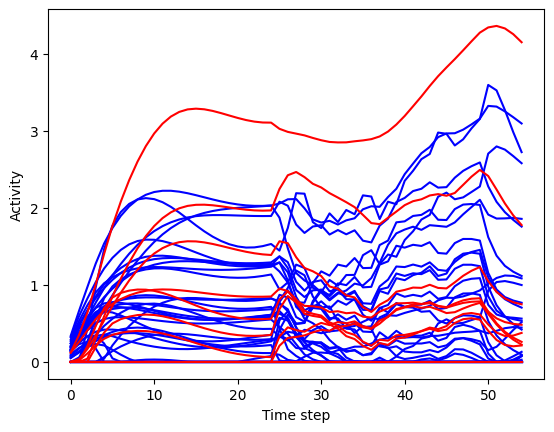

In [21]:
""" Plot teacher RNN neural activity from sample trials """
e_size = net.rnn.e_size
trial = 2

plt.figure()
_ = plt.plot(activity_dict[trial][:, :e_size], color='blue', label='Excitatory')
_ = plt.plot(activity_dict[trial][:, e_size:], color='red', label='Inhibitory')
plt.xlabel('Time step')
plt.ylabel('Activity')

In [22]:
# Student RNN and teacher RNN have the same structure
""" Train the student RNN by learning teacher's labels """
# Parameters updated during training (student_A)

# input -> hidden layer
# rnn.input2h.weight : trainable
# rnn.input2h.bias   : trainable

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : trainable
# fc.bias            : trainable

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)

student_A = Net(input_size, hidden_size, output_size, dt=env.dt, sigma_rec=0) # used to be 0.15
optimizer_A = optim.Adam(student_A.parameters(), lr=0.001)
criterion_A = nn.CrossEntropyLoss()
running_loss_A = 0
print_step = 200
step = 0
for epoch in range(20): 
    indices = np.random.permutation(len(teacher_inputs)) # length of teacher_inputs = 500
    for idx in indices: # shuffled the inputs and select one each time to learn
        inputs = torch.from_numpy(teacher_inputs[idx]).float()
        labels = torch.from_numpy(teacher_labels[idx]).long()

        optimizer_A.zero_grad()
        output_A, activity_A = student_A(inputs)
        output_A = output_A.view(-1, output_size) # reshape into (trial_time, 3)
        loss_A = criterion_A(output_A, labels)
        loss_A.backward()
        optimizer_A.step()
        running_loss_A += loss_A.item()

        step += 1
        if step % print_step == 0:
            running_loss_A /= print_step
            print('Step {}, Loss {:0.4f}'.format(step, running_loss_A))
            running_loss_A = 0

Step 200, Loss 0.3390
Step 400, Loss 0.1229
Step 600, Loss 0.0973
Step 800, Loss 0.0888
Step 1000, Loss 0.0870
Step 1200, Loss 0.0794
Step 1400, Loss 0.0844
Step 1600, Loss 0.0763
Step 1800, Loss 0.0744
Step 2000, Loss 0.0702
Step 2200, Loss 0.0826
Step 2400, Loss 0.0733
Step 2600, Loss 0.0717
Step 2800, Loss 0.0695
Step 3000, Loss 0.0700
Step 3200, Loss 0.0716
Step 3400, Loss 0.0733
Step 3600, Loss 0.0694
Step 3800, Loss 0.0687
Step 4000, Loss 0.0669
Step 4200, Loss 0.0675
Step 4400, Loss 0.0660
Step 4600, Loss 0.0698
Step 4800, Loss 0.0635
Step 5000, Loss 0.0683
Step 5200, Loss 0.0648
Step 5400, Loss 0.0604
Step 5600, Loss 0.0672
Step 5800, Loss 0.0611
Step 6000, Loss 0.0641
Step 6200, Loss 0.0621
Step 6400, Loss 0.0647
Step 6600, Loss 0.0641
Step 6800, Loss 0.0595
Step 7000, Loss 0.0660
Step 7200, Loss 0.0604
Step 7400, Loss 0.0657
Step 7600, Loss 0.0600
Step 7800, Loss 0.0574
Step 8000, Loss 0.0607
Step 8200, Loss 0.0584
Step 8400, Loss 0.0558
Step 8600, Loss 0.0615
Step 8800, Loss

In [23]:
""" Train the student RNN by learning the teacher's hidden activity r """
# Parameters updated during training (student_B)

# input -> hidden layer
# rnn.input2h.weight : trainable
# rnn.input2h.bias   : trainable

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : not updated (output not used in loss)
# fc.bias            : not updated (output not used in loss)

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)

student_B = Net(input_size, hidden_size, output_size, dt=env.dt, sigma_rec=0) # used to be 0.15
optimizer_B = optim.Adam(student_B.parameters(), lr=0.001)
criterion_B = nn.MSELoss() # Mean squared error = loss
running_loss_B = 0
print_step = 200
step = 0
for epoch in range(20):
    indices = np.random.permutation(len(teacher_inputs)) # 500
    for idx in indices:
        inputs = torch.from_numpy(teacher_inputs[idx]).float()
        target_r = torch.from_numpy(teacher_rs[idx]).float()

        optimizer_B.zero_grad()
        output_B, activity_B = student_B(inputs)
        loss_B = criterion_B(activity_B, target_r)
        loss_B.backward()
        optimizer_B.step()

        running_loss_B += loss_B.item() 
        step += 1
        if step % print_step == 0:
            running_loss_B /= print_step
            print('Step {}, Loss {:0.4f}'.format(step, running_loss_B))
            running_loss_B = 0

Step 200, Loss 0.3295
Step 400, Loss 0.2114
Step 600, Loss 0.1958
Step 800, Loss 0.1832
Step 1000, Loss 0.1866
Step 1200, Loss 0.1787
Step 1400, Loss 0.1716
Step 1600, Loss 0.1636
Step 1800, Loss 0.1687
Step 2000, Loss 0.1611
Step 2200, Loss 0.1604
Step 2400, Loss 0.1636
Step 2600, Loss 0.1608
Step 2800, Loss 0.1596
Step 3000, Loss 0.1565
Step 3200, Loss 0.1575
Step 3400, Loss 0.1592
Step 3600, Loss 0.1560
Step 3800, Loss 0.1590
Step 4000, Loss 0.1558
Step 4200, Loss 0.1589
Step 4400, Loss 0.1547
Step 4600, Loss 0.1540
Step 4800, Loss 0.1602
Step 5000, Loss 0.1526
Step 5200, Loss 0.1552
Step 5400, Loss 0.1544
Step 5600, Loss 0.1550
Step 5800, Loss 0.1540
Step 6000, Loss 0.1572
Step 6200, Loss 0.1557
Step 6400, Loss 0.1544
Step 6600, Loss 0.1536
Step 6800, Loss 0.1526
Step 7000, Loss 0.1564
Step 7200, Loss 0.1534
Step 7400, Loss 0.1543
Step 7600, Loss 0.1566
Step 7800, Loss 0.1512
Step 8000, Loss 0.1555
Step 8200, Loss 0.1545
Step 8400, Loss 0.1533
Step 8600, Loss 0.1560
Step 8800, Loss

In [24]:
# learn teacher's every logit, loss = 0.16
# learn every time step probability distribution, loss = 0.01
# learn the last step logit, loss = 0.03
# Train the student network by the final step probability distribution but using teacher's input->hidden & hidden-> output layer, loss = 3.20
""" Train student RNN by learning teacher's final-step behavior probability distribution """
# Parameters updated during training (student_C)

# input -> hidden layer
# rnn.input2h.weight : trainable
# rnn.input2h.bias   : trainable

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : trainable
# fc.bias            : trainable

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)

student_C = Net(input_size, hidden_size, output_size, dt=env.dt, sigma_rec=0) # used to be 0.15
optimizer_C = optim.Adam(student_C.parameters(), lr=0.001)
criterion_C = nn.KLDivLoss(reduction='batchmean') # learn the probability distribution

running_loss_C = 0
print_step = 200
step = 0
temperature = 1.0
for epoch in range(20):
    indices = np.random.permutation(len(teacher_inputs))

    for idx in indices:
        inputs = torch.from_numpy(teacher_inputs[idx]).float()
        target_output = torch.from_numpy(teacher_outputs[idx]).float()
        optimizer_C.zero_grad()
        output_C, activity_C = student_C(inputs)
        # only learn the last step
        teacher_prob = torch.softmax(target_output[-1, 0, :] / temperature, dim=-1) # target has to be probability
        student_logprob = torch.log_softmax(output_C[-1, 0, :] / temperature, dim=-1) # input has to be log probability
        loss_C = criterion_C(student_logprob, teacher_prob)
        loss_C.backward()
        optimizer_C.step()

        running_loss_C += loss_C.item()
        step += 1
        if step % print_step == 0:
            running_loss_C /= print_step
            print('Step {}, Loss {:0.4f}'.format(step, running_loss_C))
            running_loss_C = 0

Step 200, Loss 0.1421
Step 400, Loss 0.1121
Step 600, Loss 0.0534
Step 800, Loss 0.0240
Step 1000, Loss 0.0134
Step 1200, Loss 0.0109
Step 1400, Loss 0.0057
Step 1600, Loss 0.0059
Step 1800, Loss 0.0040
Step 2000, Loss 0.0069
Step 2200, Loss 0.0049
Step 2400, Loss 0.0057
Step 2600, Loss 0.0042
Step 2800, Loss 0.0036
Step 3000, Loss 0.0038
Step 3200, Loss 0.0025
Step 3400, Loss 0.0030
Step 3600, Loss 0.0018
Step 3800, Loss 0.0020
Step 4000, Loss 0.0019
Step 4200, Loss 0.0024
Step 4400, Loss 0.0024
Step 4600, Loss 0.0012
Step 4800, Loss 0.0018
Step 5000, Loss 0.0028
Step 5200, Loss 0.0022
Step 5400, Loss 0.0016
Step 5600, Loss 0.0017
Step 5800, Loss 0.0016
Step 6000, Loss 0.0033
Step 6200, Loss 0.0014
Step 6400, Loss 0.0012
Step 6600, Loss 0.0009
Step 6800, Loss 0.0017
Step 7000, Loss 0.0008
Step 7200, Loss 0.0014
Step 7400, Loss 0.0009
Step 7600, Loss 0.0008
Step 7800, Loss 0.0009
Step 8000, Loss 0.0007
Step 8200, Loss 0.0018
Step 8400, Loss 0.0008
Step 8600, Loss 0.0011
Step 8800, Loss

In [25]:
""" Train the student network by learning r but using teacher's input->hidden layer """
# Parameters updated during training (student_D)

# input -> hidden layer
# rnn.input2h.weight : not trainable (same as teacher)
# rnn.input2h.bias   : not trainable (same as teacher)

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : not updated (output not used in loss)
# fc.bias            : not updated (output not used in loss)

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)
def train_student_D(epochs=20, lr=0.001, name="D"):
    student = Net(input_size=input_size,
                  hidden_size=hidden_size,
                  output_size=output_size,
                  dt=env.dt,
                  sigma_rec=0)
    
    # Copy teacher (net) input -> hidden layer
    student.rnn.input2h.load_state_dict(net.rnn.input2h.state_dict())

    # Freeze everything first
    for p in student.parameters():
        p.requires_grad = False
    
    # Only train recurrent weight; optionally train recurrent bias (bias is NOT noise)
    student.rnn.h2h.weight.requires_grad = True
    if student.rnn.h2h.bias is not None: # since in EIRecLinear, bias = False (teacher bias equal to None), so the sentence is always not satisfied
        student.rnn.h2h.bias.requires_grad = True

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, student.parameters()), lr=lr)
    criterion = nn.MSELoss()

    running_loss = 0
    print_step = 200
    step = 0
    last_loss = None

    for epoch in range(epochs):
        indices = np.random.permutation(len(teacher_inputs))

        for idx in indices:
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            target_r = torch.from_numpy(teacher_rs[idx]).float()

            optimizer.zero_grad()
            output, activity = student(inputs)
            loss = criterion(activity, target_r)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            last_loss = loss.item()
            step += 1

            if step % print_step == 0:
                running_loss /= print_step
                print(f'Step {step}, Loss {running_loss:.4f}')
                running_loss = 0
    return student, last_loss

# student D has the same input->hidden layer as the teacher, and fit hidden layer weight only 
student_D, loss_D = train_student_D(epochs=20, lr=0.001, name="D activity-trained weight-only")

Step 200, Loss 0.1638
Step 400, Loss 0.0526
Step 600, Loss 0.0431
Step 800, Loss 0.0345
Step 1000, Loss 0.0315
Step 1200, Loss 0.0289
Step 1400, Loss 0.0280
Step 1600, Loss 0.0282
Step 1800, Loss 0.0276
Step 2000, Loss 0.0251
Step 2200, Loss 0.0258
Step 2400, Loss 0.0253
Step 2600, Loss 0.0251
Step 2800, Loss 0.0241
Step 3000, Loss 0.0242
Step 3200, Loss 0.0243
Step 3400, Loss 0.0243
Step 3600, Loss 0.0237
Step 3800, Loss 0.0231
Step 4000, Loss 0.0242
Step 4200, Loss 0.0243
Step 4400, Loss 0.0233
Step 4600, Loss 0.0223
Step 4800, Loss 0.0241
Step 5000, Loss 0.0236
Step 5200, Loss 0.0246
Step 5400, Loss 0.0221
Step 5600, Loss 0.0222
Step 5800, Loss 0.0238
Step 6000, Loss 0.0236
Step 6200, Loss 0.0238
Step 6400, Loss 0.0213
Step 6600, Loss 0.0241
Step 6800, Loss 0.0228
Step 7000, Loss 0.0239
Step 7200, Loss 0.0233
Step 7400, Loss 0.0236
Step 7600, Loss 0.0217
Step 7800, Loss 0.0227
Step 8000, Loss 0.0241
Step 8200, Loss 0.0210
Step 8400, Loss 0.0240
Step 8600, Loss 0.0229
Step 8800, Loss

In [26]:
""" Evaluation """
def get_recurrent_weight(model):
    if hasattr(model.rnn.h2h, "effective_weight"): # if there is attribute effective_weight 
        return model.rnn.h2h.effective_weight().detach().numpy()
    return model.rnn.h2h.weight.detach().numpy()

def weight_corr(W_teacher, W_student):
    corr_signed = np.corrcoef(W_teacher.flatten(), W_student.flatten())[0, 1]
    corr_abs = np.corrcoef(np.abs(W_teacher).flatten(), np.abs(W_student).flatten())[0, 1]
    return corr_signed, corr_abs

def evaluate_activity_mse(student): # compare teacher r and student r
    criterion = nn.MSELoss()
    total_loss = 0
    n = 0
    with torch.no_grad():
        indices = range(len(teacher_inputs))
        for idx in indices:
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            target_r = torch.from_numpy(teacher_rs[idx]).float()
            _, activity = student(inputs)
            loss = criterion(activity, target_r)
            total_loss += loss.item()
            n += 1
    return total_loss / n

def evaluate_accuracy(student):
    correct_list = []
    with torch.no_grad():
        indices = range(len(teacher_inputs))
        for idx in indices:
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            labels = torch.from_numpy(teacher_labels[idx]).long()
            output, _ = student(inputs)
            # final-step choice
            choice = torch.argmax(output[-1, 0, :]).item()
            correct = choice == labels[-1].item()
            correct_list.append(correct)
    return np.mean(correct_list)

students_for_eval = [
    ("A label-trained", student_A),
    ("B activity-trained", student_B),
    ("C final-probability-trained", student_C),
    ("D activity-trained weight-only", student_D),
]
W_teacher = get_recurrent_weight(net)

eval_results = []
for name, student in students_for_eval:
    W_student = get_recurrent_weight(student)
    corr_signed, corr_abs = weight_corr(W_teacher, W_student)
    mean_mse = evaluate_activity_mse(student)
    mean_acc = evaluate_accuracy(student)
    eval_results.append({
        "name": name,
        "activity_mse": mean_mse,
        "accuracy": mean_acc,
        "signed_corr": corr_signed,
        "abs_corr": corr_abs,
        "diagonal_zero": np.allclose(np.diag(W_student), 0),
    })
for result in eval_results:
    print(result["name"])
    print("  activity MSE:", result["activity_mse"])
    print("  accuracy:", result["accuracy"])
    print("  signed W corr:", result["signed_corr"])
    print("  abs W corr:", result["abs_corr"])
    print("  diagonal zero:", result["diagonal_zero"])

A label-trained
  activity MSE: 6.306161805152893
  accuracy: 0.8
  signed W corr: 0.3925031589398432
  abs W corr: 0.1390719412102479
  diagonal zero: True
B activity-trained
  activity MSE: 0.1534544769525528
  accuracy: 0.47
  signed W corr: 0.536292113988429
  abs W corr: 0.41006027062151085
  diagonal zero: True
C final-probability-trained
  activity MSE: 0.7213353841304779
  accuracy: 0.832
  signed W corr: 0.3501234493513193
  abs W corr: 0.11459959261959071
  diagonal zero: True
D activity-trained weight-only
  activity MSE: 0.022950352054089306
  accuracy: 0.346
  signed W corr: 0.7470531700446088
  abs W corr: 0.6799738219921357
  diagonal zero: True


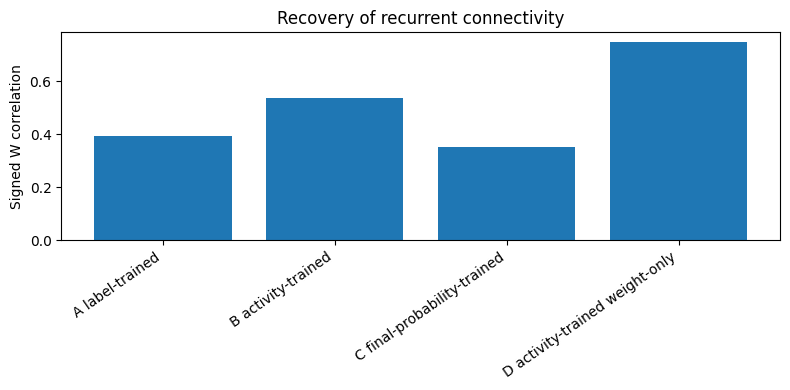

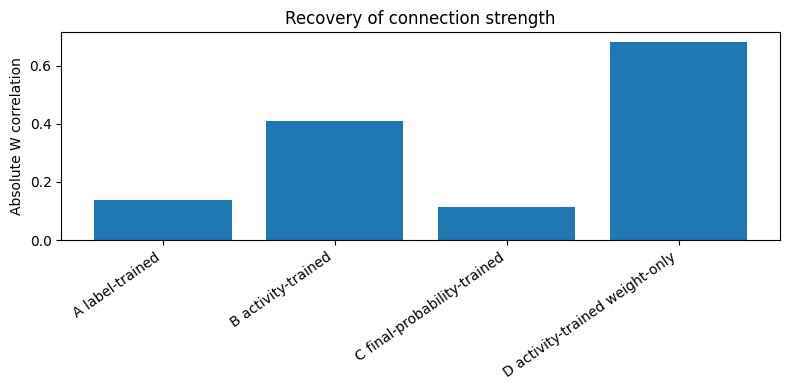

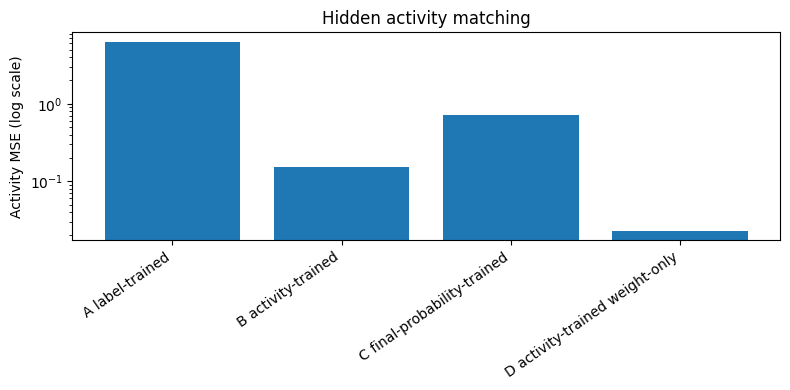

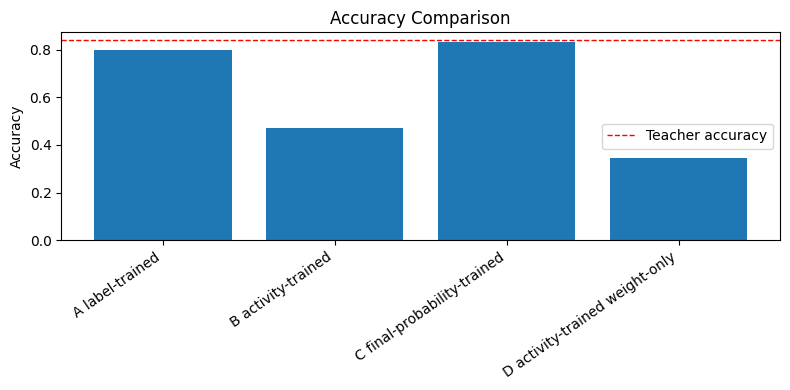

In [27]:
""" Summary plots """
names = [r["name"] for r in eval_results]
activity_mse = [r["activity_mse"] for r in eval_results]
signed_corr = [r["signed_corr"] for r in eval_results]
abs_corr = [r["abs_corr"] for r in eval_results]
accuracy = [r["accuracy"] for r in eval_results]

plt.figure(figsize=(8, 4))
plt.bar(names, signed_corr)
plt.ylabel("Signed W correlation")
plt.xticks(rotation=35, ha="right")
plt.title("Recovery of recurrent connectivity")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, abs_corr)
plt.ylabel("Absolute W correlation")
plt.xticks(rotation=35, ha="right")
plt.title("Recovery of connection strength")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, activity_mse)
plt.yscale("log")
plt.ylabel("Activity MSE (log scale)")
plt.xticks(rotation=35, ha="right")
plt.title("Hidden activity matching")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, accuracy)
plt.axhline(teacher_accuracy, linestyle='--', linewidth=1, color='r', label='Teacher accuracy')
plt.ylabel("Accuracy")
plt.xticks(rotation=35, ha="right")
plt.title("Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.show()


Explained variance ratio:
PC1: 0.39492786
PC2: 0.3142747
PC3: 0.16917175
Total: 0.8783743
Teacher PC1-3 explain: 0.15360388
Teacher PC1-3 explain: 0.6356493
Teacher PC1-3 explain: 0.08767321
Teacher PC1-3 explain: 0.8353922


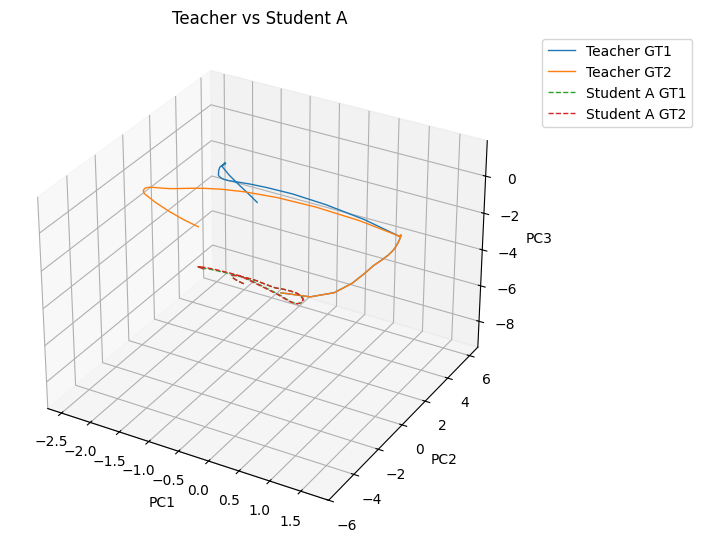

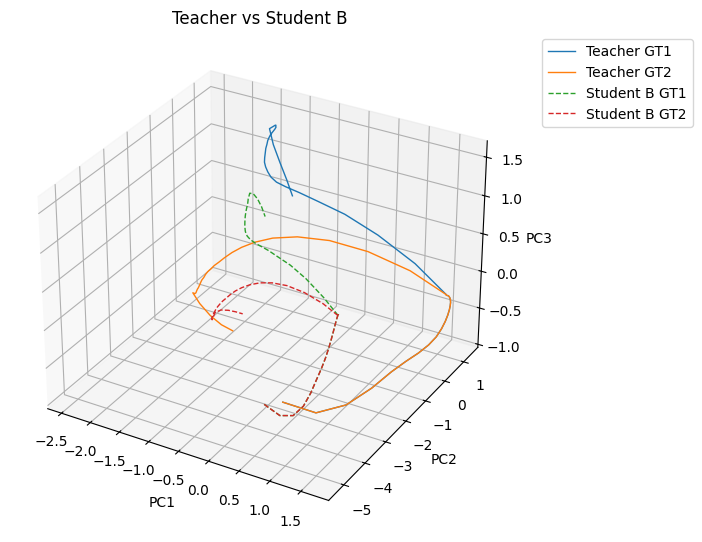

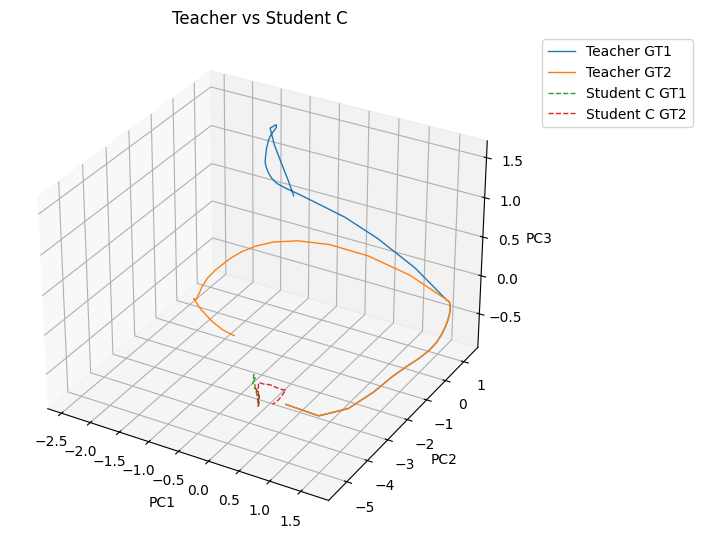

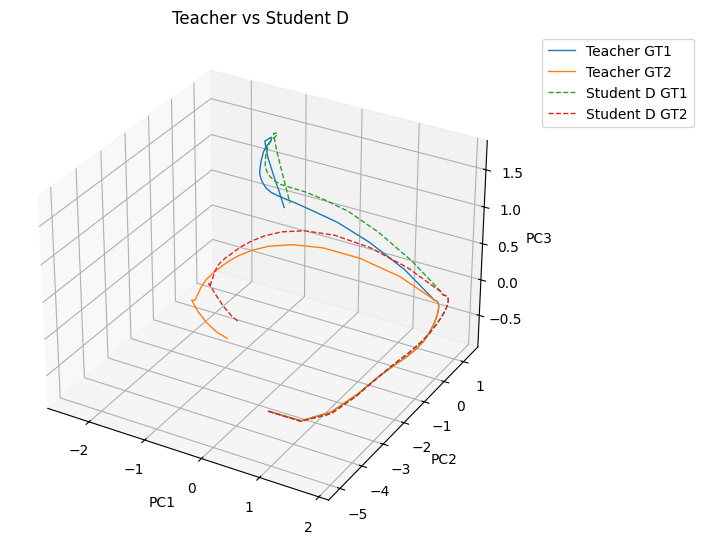

In [ ]:
""" PCA comparison between teacher and students """
from sklearn.decomposition import PCA
# teacher activity
T = activity_dict[0].shape[0] # time of trial (55)
H = activity_dict[0].shape[1] # hidden size (50)
n_trial = len(activity_dict) # 500
teacher_activity = np.stack([activity_dict[i] for i in range(n_trial)], axis=0) # (n_trial, trial_time, hidden_size)
teacher_flat = teacher_activity.reshape(-1, H) # PCA require input with (sample=n_trial*trial_time, feature=neuron) 

# PCA on teacher
pca = PCA(n_components=3)
teacher_pca_flat = pca.fit_transform(teacher_flat) # -> (sample, 3), used to be 2
teacher_pca = teacher_pca_flat.reshape(n_trial, T, 3)
print("Explained variance ratio:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("PC3:", pca.explained_variance_ratio_[2])
print("Total:", np.sum(pca.explained_variance_ratio_)) # explain about 90% of variance

# get student activity
def get_student_activity(student):
    student_activity = []
    with torch.no_grad():
        for idx in range(len(teacher_inputs)):
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            _, activity = student(inputs)
            activity = (activity[:, 0, :].detach().cpu().numpy())
            student_activity.append(activity)
    return np.stack(student_activity, axis=0)

# project student to teacher PCA space
def project_to_teacher_pca(student):
    student_activity = get_student_activity(student)
    student_flat = student_activity.reshape(-1, H)
    student_pca_flat = pca.transform(student_flat) # project onto 3 PCs of teacher
    student_pca = student_pca_flat.reshape(student_activity.shape[0], student_activity.shape[1], 3)
    # how much of student's variance can be explained by teacher's 3 PCs
    student_total_var = np.var(student_flat, axis=0).sum()
    student_pc_var = np.var(student_pca_flat, axis=0).sum()
    explained_ratio = (student_pc_var/student_total_var)
    print("Teacher PC1-3 explain:", explained_ratio)
    return student_pca, explained_ratio

student_A_pca, student_A_pca_overlap = project_to_teacher_pca(student_A)
student_B_pca, student_B_pca_overlap = project_to_teacher_pca(student_B)
student_C_pca, student_C_pca_overlap = project_to_teacher_pca(student_C)
student_D_pca, student_D_pca_overlap = project_to_teacher_pca(student_D)

# plot teacher vs one student
def plot_teacher_student_pca(student_pca, student_name): # average the outcome based on different ground truth
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(projection='3d')
    # separate by ground truth
    gt1_idx = []
    gt2_idx = []
    for i in range(n_trial):
        gt = teacher_labels[i][-1]
        if gt == 1:
            gt1_idx.append(i)
        else:
            gt2_idx.append(i)
    # mean trajectory
    teacher_mean_1 = np.mean(teacher_pca[gt1_idx], axis=0)
    teacher_mean_2 = np.mean(teacher_pca[gt2_idx], axis=0)

    student_mean_1 = np.mean(student_pca[gt1_idx], axis=0)
    student_mean_2 = np.mean(student_pca[gt2_idx], axis=0)

    ax.plot(teacher_mean_1[:,0], teacher_mean_1[:,1], teacher_mean_1[:,2], linewidth=1, label='Teacher GT1')
    ax.plot(teacher_mean_2[:,0], teacher_mean_2[:,1], teacher_mean_2[:,2], linewidth=1, label='Teacher GT2')
    ax.plot(student_mean_1[:,0], student_mean_1[:,1], student_mean_1[:,2], '--', linewidth=1, label=f'{student_name} GT1')
    ax.plot(student_mean_2[:,0], student_mean_2[:,1], student_mean_2[:,2], '--', linewidth=1, label=f'{student_name} GT2')

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(f'Teacher vs {student_name}')
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.subplots_adjust(right=0.75)
    plt.show()
    
plot_teacher_student_pca(student_A_pca, "Student A")
plot_teacher_student_pca(student_B_pca, "Student B")
plot_teacher_student_pca(student_C_pca, "Student C")
plot_teacher_student_pca(student_D_pca, "Student D") # best

In [ ]:
""" Save results """
import json
results = {
    # teacher PCAs
    "pca_pc1": float(pca.explained_variance_ratio_[0]),
    "pca_pc2": float(pca.explained_variance_ratio_[1]),
    "pca_pc3": float(pca.explained_variance_ratio_[2]),
    "pca_total_3pc": float(np.sum(pca.explained_variance_ratio_[:3])),

    # student PCA overlap
    "A_pca_overlap": float(student_A_pca_overlap),
    "B_pca_overlap": float(student_B_pca_overlap),
    "C_pca_overlap": float(student_C_pca_overlap),
    "D_pca_overlap": float(student_D_pca_overlap),

    # accuracy
    "A_accuracy": float(eval_results[0]["accuracy"]),
    "B_accuracy": float(eval_results[1]["accuracy"]),
    "C_accuracy": float(eval_results[2]["accuracy"]),
    "D_accuracy": float(eval_results[3]["accuracy"]),

    # activity MSE
    "A_activity_mse": float(eval_results[0]["activity_mse"]),
    "B_activity_mse": float(eval_results[1]["activity_mse"]),
    "C_activity_mse": float(eval_results[2]["activity_mse"]),
    "D_activity_mse": float(eval_results[3]["activity_mse"]),

    # W correlation
    "A_signed_corr": float(eval_results[0]["signed_corr"]),
    "B_signed_corr": float(eval_results[1]["signed_corr"]),
    "C_signed_corr": float(eval_results[2]["signed_corr"]),
    "D_signed_corr": float(eval_results[3]["signed_corr"]),
}
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("results saved")